In [7]:
import pandas as pd
import numpy as np
import time
import warnings
from numba import njit
from juejing import get_stock_klines_from_juejing
from SuperSSF import ssf, compute_grid_coupling
warnings.filterwarnings('ignore', category=UserWarning)


In [ ]:
def process_single_stock(code, end_date, tail_days, name):
    print(f'正在处理 {name}...')
    get_data_start = time.perf_counter()

    df = get_stock_klines_from_juejing(code, end_date, fqt=1)
    get_data_end = time.perf_counter()
    print(f'获取数据耗时: {get_data_end - get_data_start:.3f} 秒')

    df = df[df['close'] > 0]

    df['pct_chg'] = df['close'].pct_change() * 100
    df['pct_chg'] = df['pct_chg'].round(2)
    df['ssf_s'] = ssf(close=df.close, length=60, poles=3)
    df['ssf_m'] = ssf(close=df.close, length=120, poles=3)
    df['ssf_l'] = ssf(close=df.close, length=250, poles=3)

    # 计算格栅线耦合
    grid_result = compute_grid_coupling(df)
    df['grid_coupling'] = grid_result

    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    plot_df = df.tail(tail_days)
    calc_end = time.perf_counter()
    print(f'计算指标耗时: {calc_end - get_data_end:.3f} 秒')

    # 画图
    import mplfinance as mpl
    import matplotlib.pyplot as plt
    add_plot = [
        mpl.make_addplot(plot_df['ssf_m'], color='red', width=1.5, secondary_y=False, label='SuperBase'),
        mpl.make_addplot(plot_df['ssf_l'], color='blue', width=1.0, secondary_y=False, label='SuperLong'),
        # mpl.make_addplot(plot_df['ssf_s'], color='orange', width=1.0, secondary_y=False, label='SuperShort'),
        mpl.make_addplot(plot_df['grid_coupling'], type='scatter', color='red', markersize=10, secondary_y=False, label='GridCoupling'),
    ]
    mc = mpl.make_marketcolors(up='red', down='green', edge='inherit', wick='inherit', volume='inherit')
    s = mpl.make_mpf_style(marketcolors=mc, gridstyle='-', y_on_right=False)
    fig, ax = mpl.plot(
        plot_df, type='candle', style=s,
        title=f'{name} - end:{end_date})',
        ylabel='price', ylabel_lower='volume', volume=True,
        addplot=add_plot, figratio=(22, 10), figscale=2, returnfig=True
    )
    ax[0].legend(loc='upper left')
    plt.show()
    plt.close()
    plt_end = time.perf_counter()
    print(f'画图耗时: {plt_end - calc_end:.3f} 秒')


正在处理 300437...
正在获取 300437 的数据 (尝试 1/3)...
成功获取 300437 的 1377 条数据
获取数据耗时: 0.070 秒
计算指标耗时: 0.012 秒


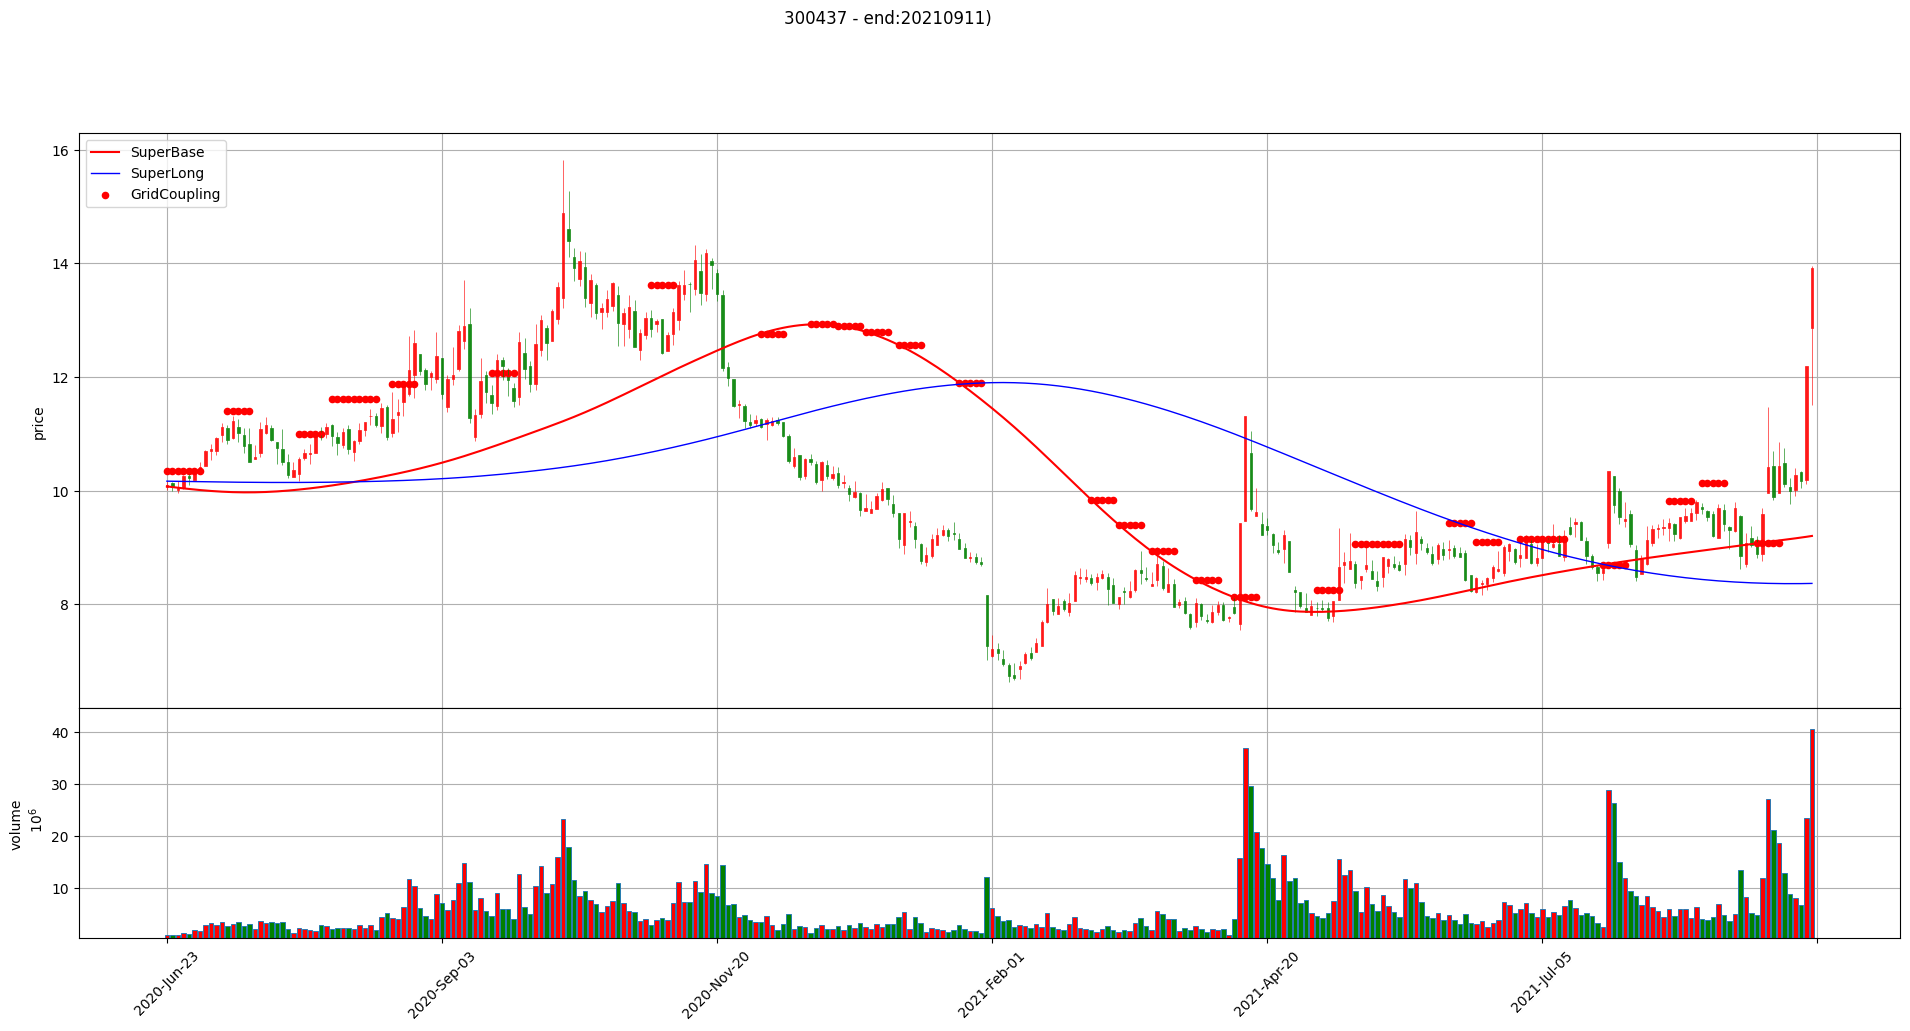

画图耗时: 0.446 秒
全部处理完成！


In [9]:
def main():
    stocks = [
        # ('300843', '20250930', 200, '300843'),
        # ('688202', '20250930', 200, '688202'),
        # ('301308', '20250930', 200, '301308'),
        # ('002213', '20250930', 200, '002213'),
        # ('603061', '20251230', 200, '603061'),
        # ('603893', '20251230', 200, '603893'),
        # ('002580', '20250330', 200, '002580'),
        # ('603301', '20250915', 200, '603301'),
        # ('603256', '20250715', 200, '603256'),
        # ('600403', '20251010', 200, '600403'),
        # ('603773', '20261010', 200, '603773'),
        # ('300408', '20261010', 200, '300408'),
        # ('002765', '20241111', 200, '002765'),
        # ('300113', '20250311', 200, '300113'),
        # ('300031', '20250311', 200, '300031'),
        # ('600980', '20250311', 200, '600980'),
        # ('688099', '20251111', 300, '688099'),
        # ('300437', '20251111', 300, '300437'),
        ('300437', '20210911', 300, '300437'),
    ]
    for code, end_date, tail_days, name in stocks:
        process_single_stock(code, end_date, tail_days, name)
    print('全部处理完成！')

if __name__ == '__main__':
    main()
